In [1]:
import pandas as pd

In [2]:
columns = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT', 'MEDV']
df = pd.read_csv('housing.csv', header=None, sep=r"\s+", names=columns, nrows = None)

In [3]:
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273.0,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273.0,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273.0,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273.0,21.0,393.45,6.48,22.0


## Análise exploratória e Entendimento do Problema


- CRIM: taxa de criminalidade per capita por cidade.
- ZN: Percentual de terrenos residenciais grandes.
- INDUS: Percentual de área ocupada por indústrias não comerciais.
- CHAS: Se o bairro faz fronteira com o Rio Charles (1 = sim, 0 = não).
- NOX: Nível de poluição do ar (óxidos nítricos).
- RM: Número médio de quartos por casa.
- AGE: Percentual de casas antigas (construídas antes de 1940).
- DIS: Proximidade aos centros de emprego de Boston.
- RAD: Facilidade de acesso a rodovias.
- TAX: Taxa de imposto sobre a propriedade.
- PTRATIO: Número de alunos por professor nas escolas da cidade.
- B: Medida relacionada à proporção de residentes negros na cidade.
- LSTAT: Percentual de pessoas de baixa renda.
- MEDV: Valor mediano das casas em milhares de dólares.

In [4]:
df.shape

(506, 14)

### Dsitruibuição dos dados

In [5]:
df.describe(include="all")

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


Aparentemente os dados tem uma grande dispersão em relação a média, se olharmos a média da variável e seu desvio padrão.

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

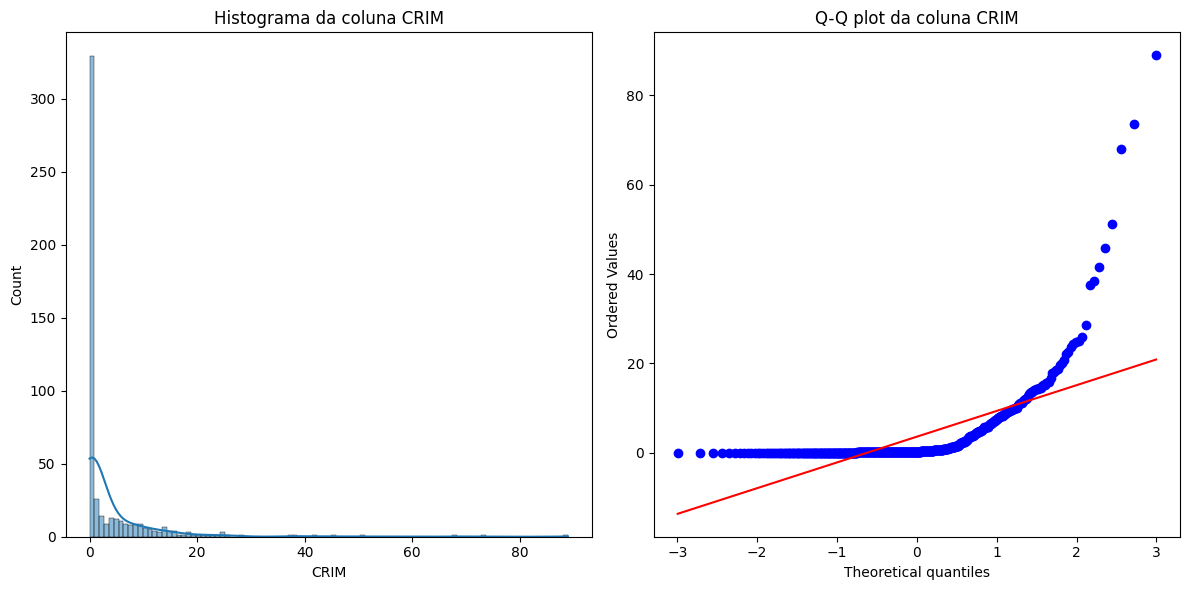

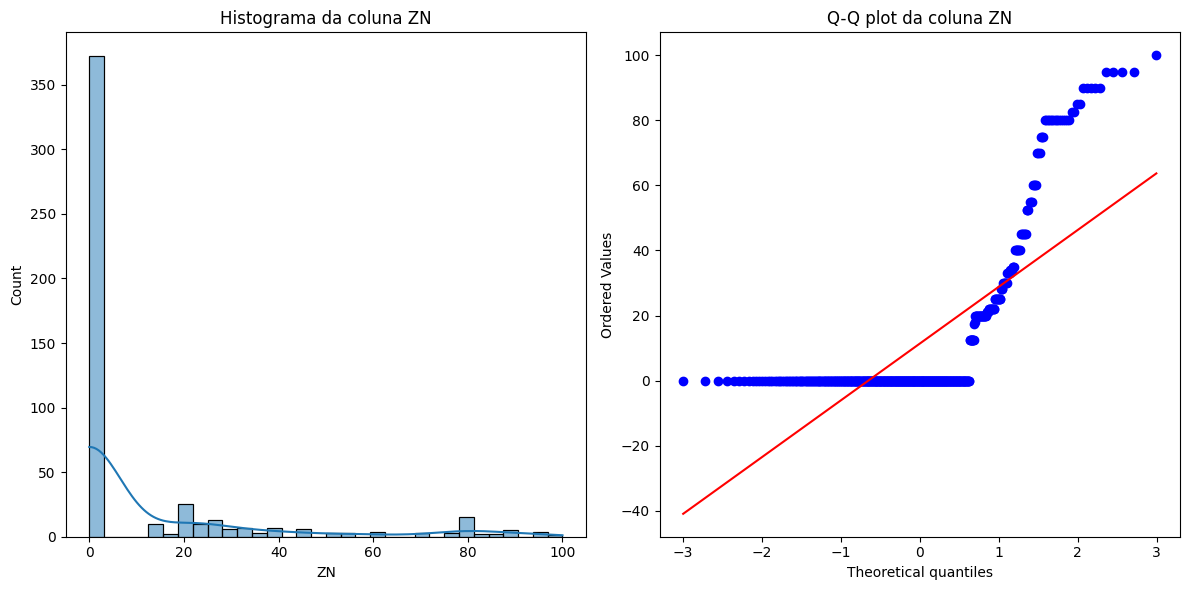

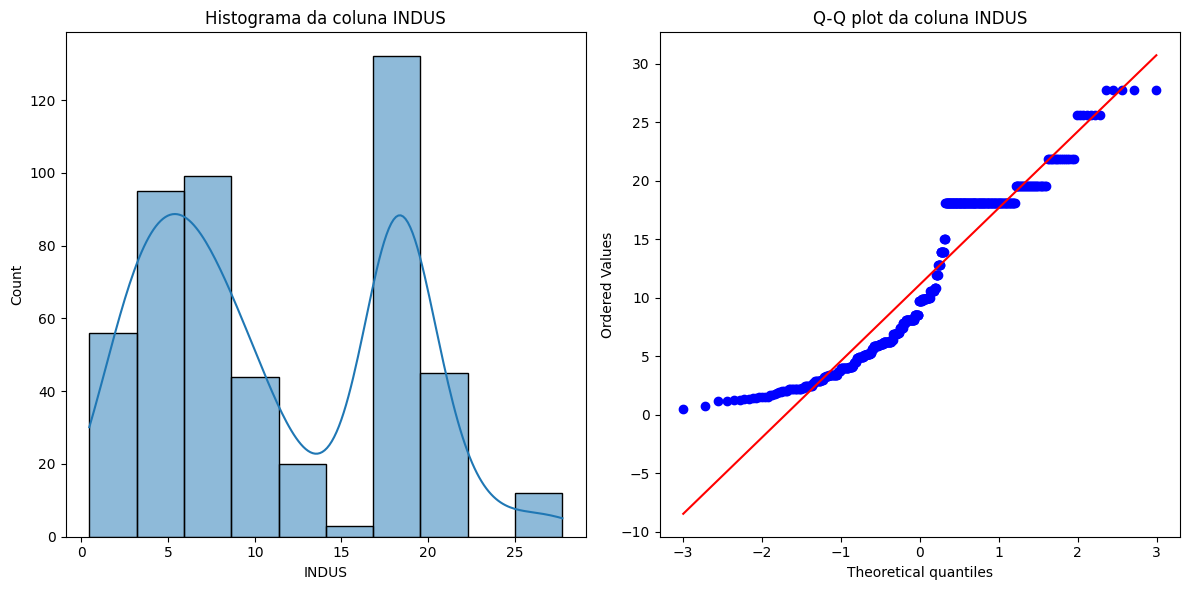

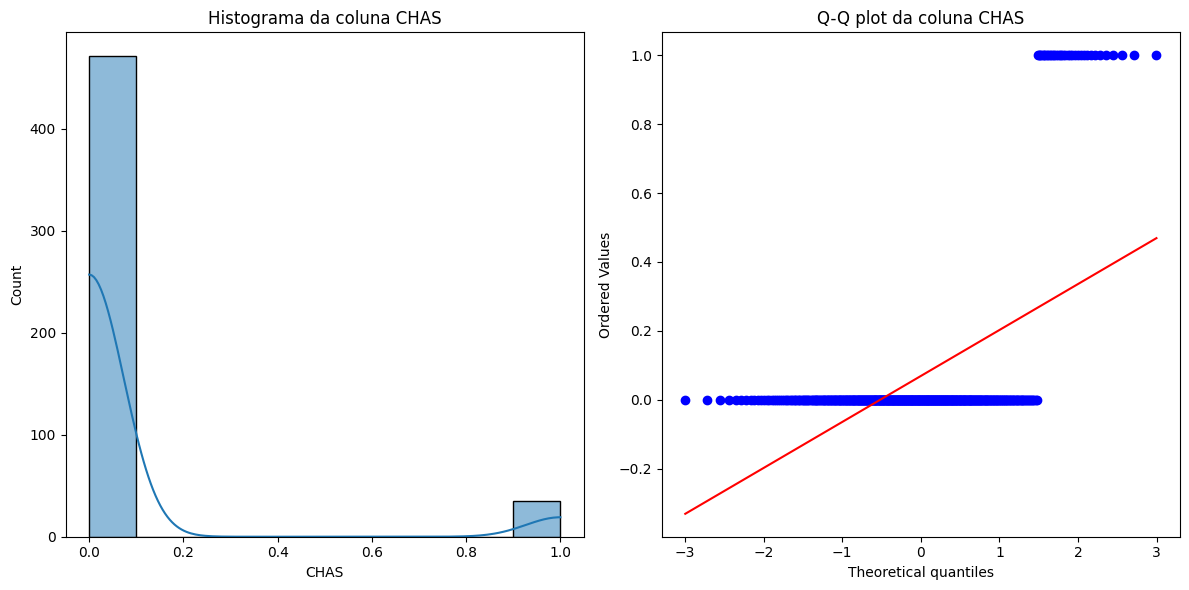

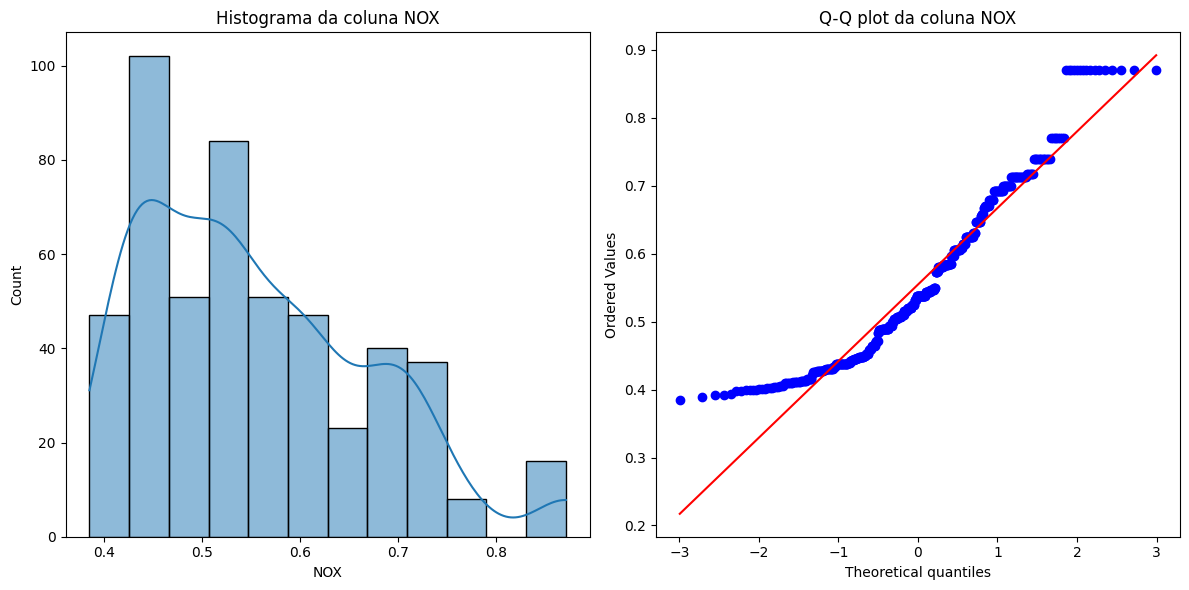

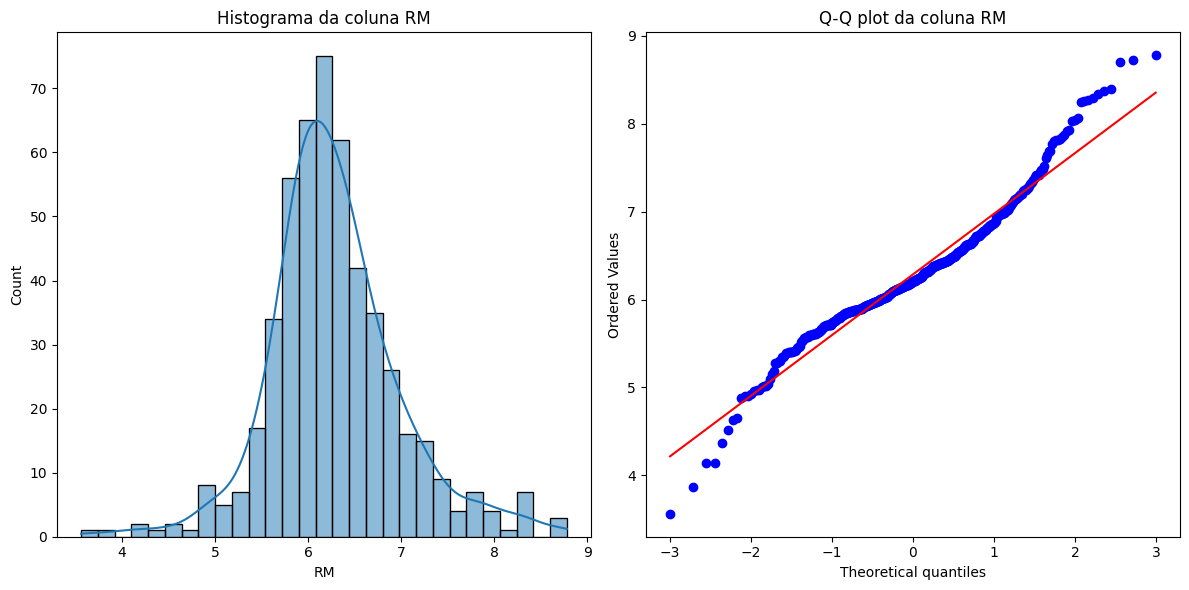

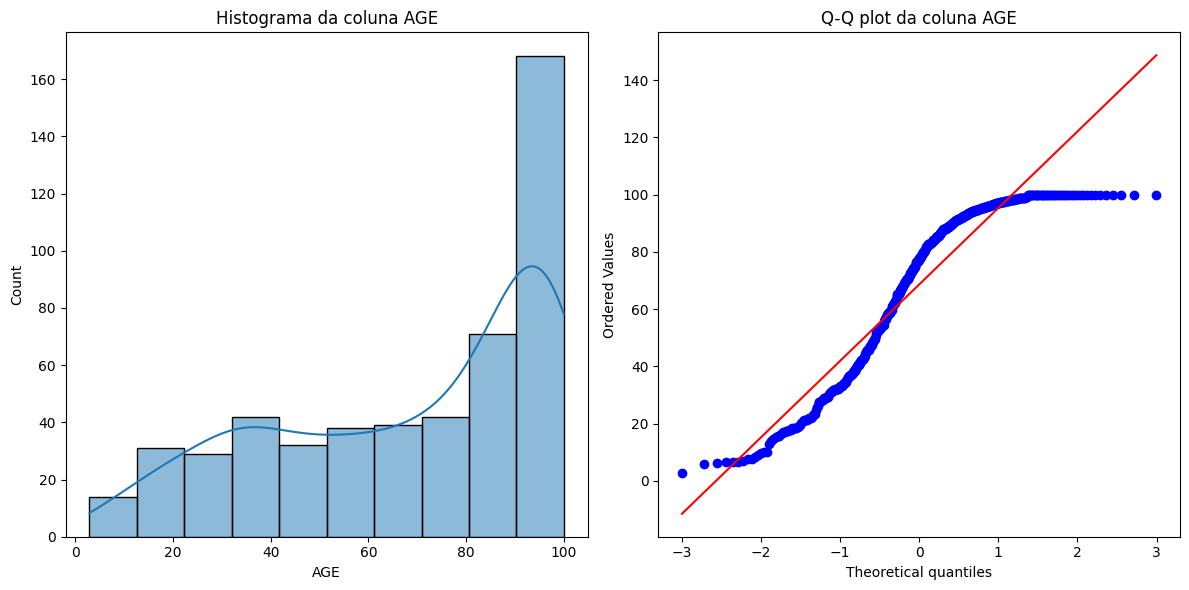

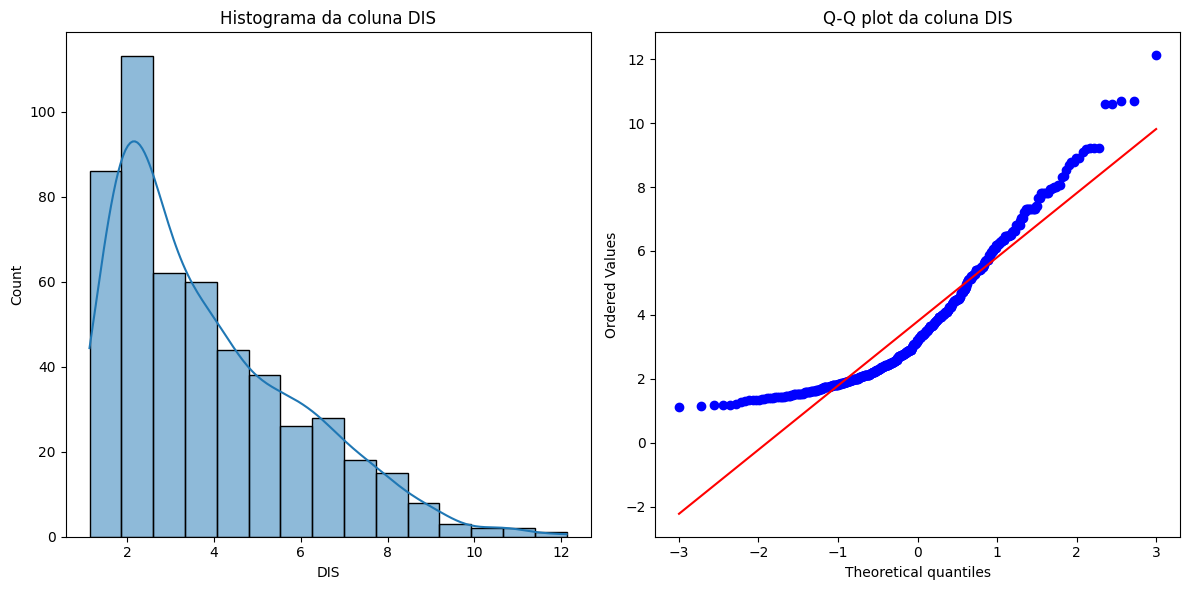

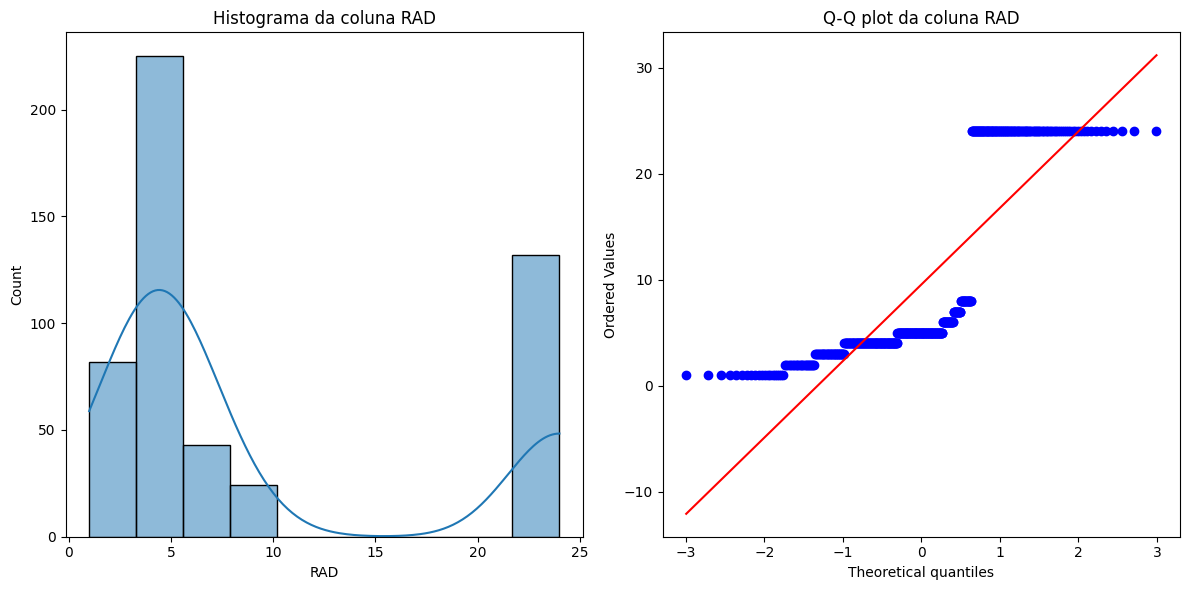

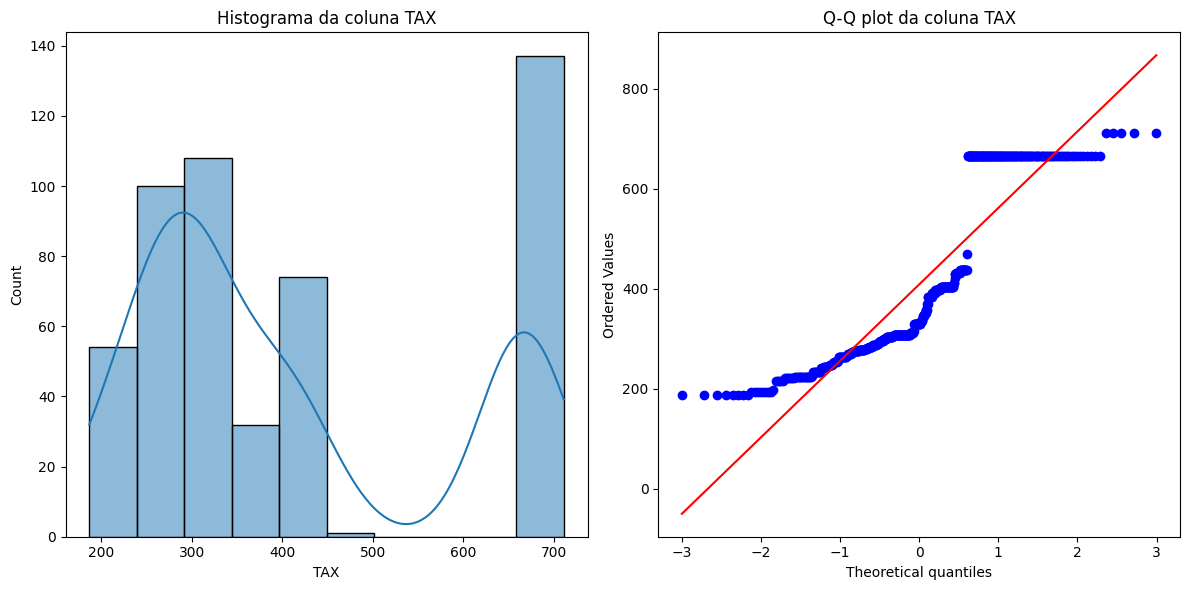

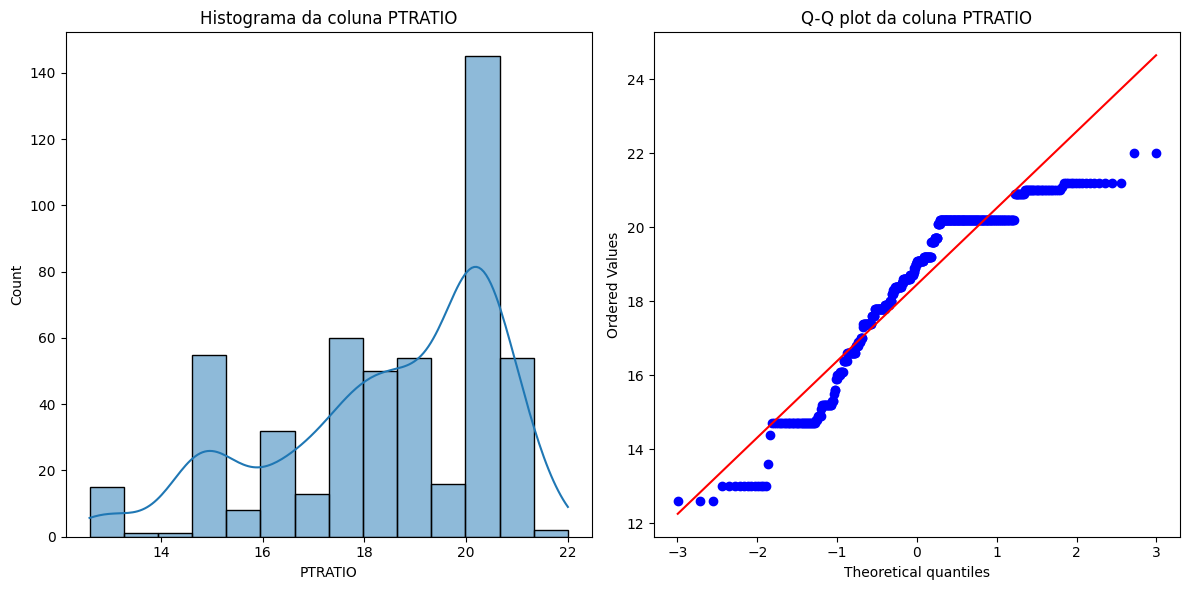

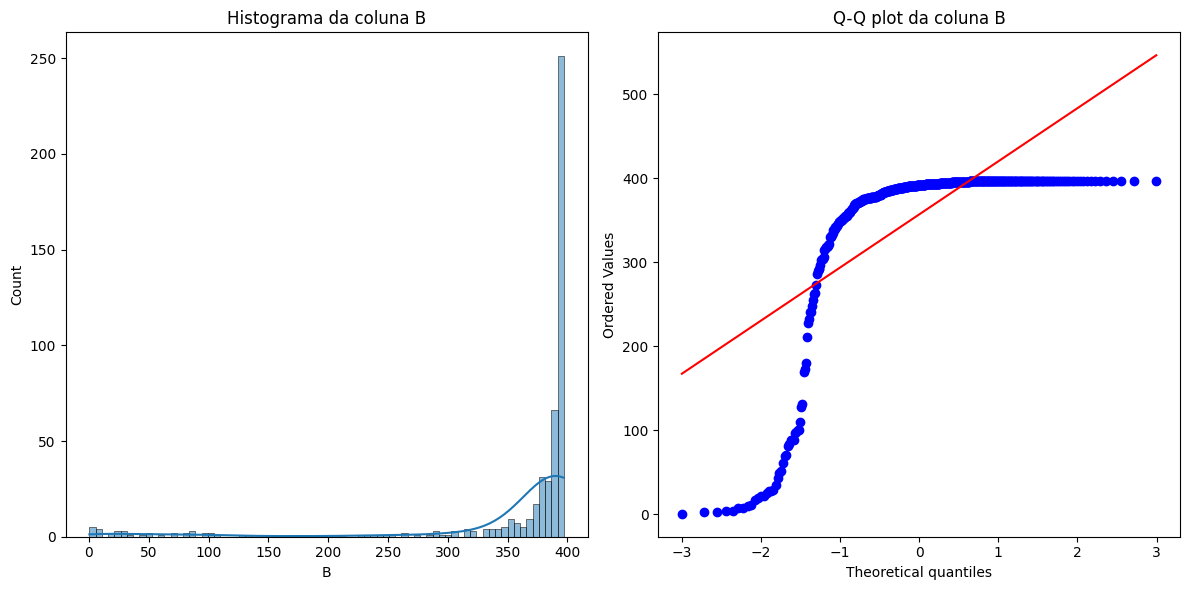

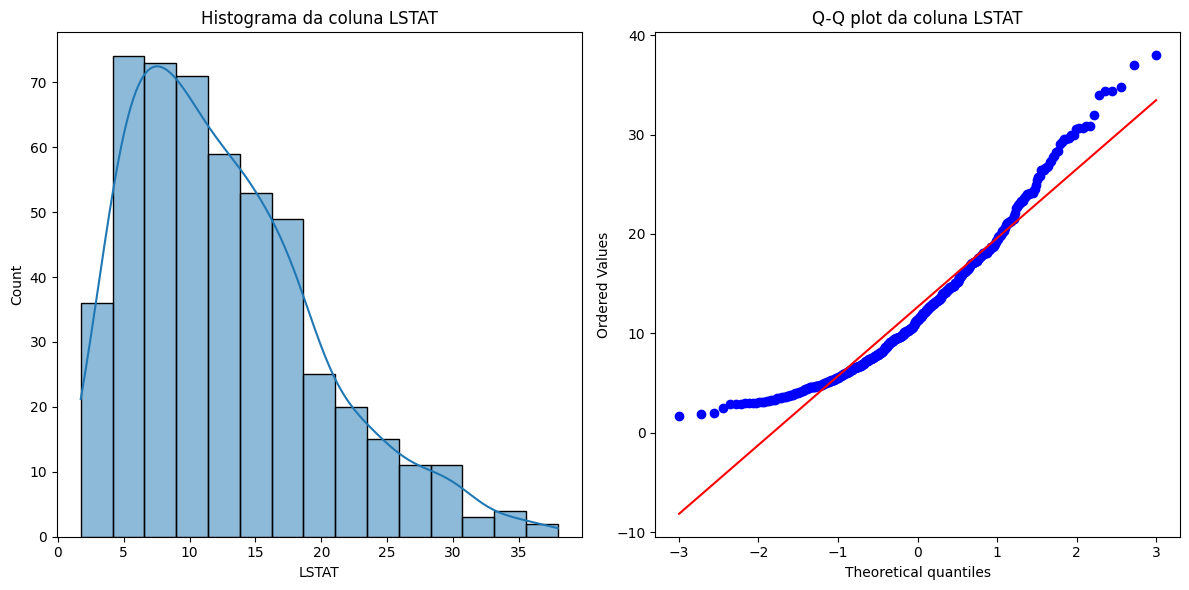

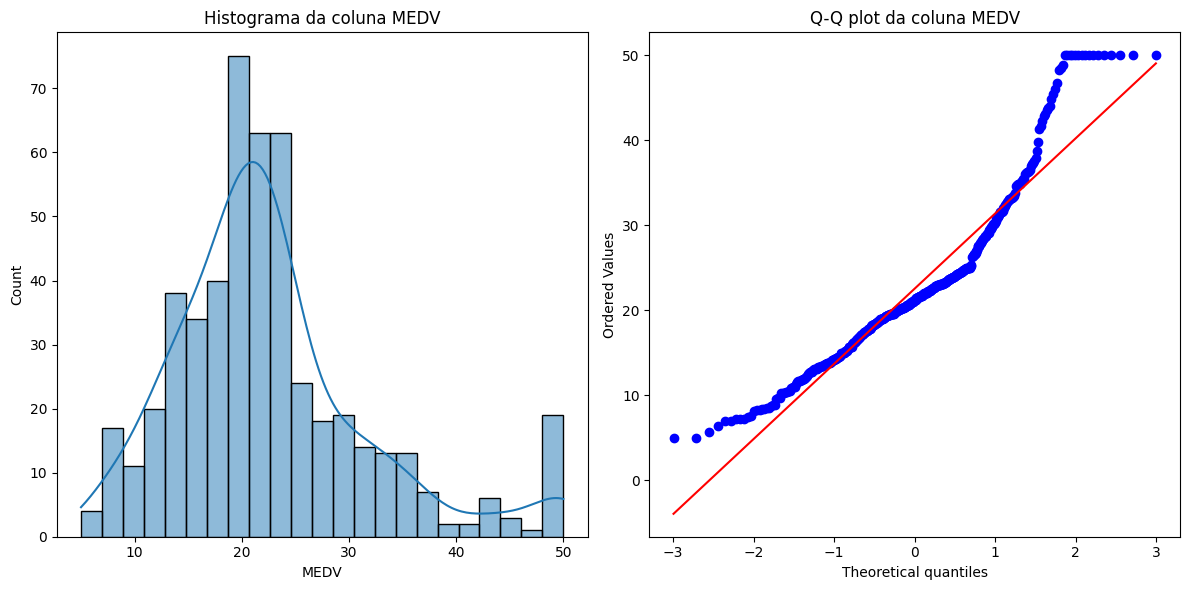

In [7]:
def plot_distribution(coluns: list):
  for col in coluns:
    plt.figure(figsize=(12, 6))
    plt.subplot(1, 2, 1)
    sns.histplot(df[col], kde=True)
    plt.title(f'Histograma da coluna {col}')

    plt.subplot(1, 2, 2)
    stats.probplot(df[col], dist="norm", plot=plt)
    plt.title(f'Q-Q plot da coluna {col}')

    plt.tight_layout()
    plt.show()


plot_distribution(columns)


Os dados em geral, apesar da distribuição parecer possuir algumas características ligeiramente parecidas com a distribuição normal, não possuem de fato isso em sua maioria. Algumas variáveis como CHAS e ZN possuem outliers visíveis.

## Correlação

In [8]:
correlation = df.corr()

<Axes: >

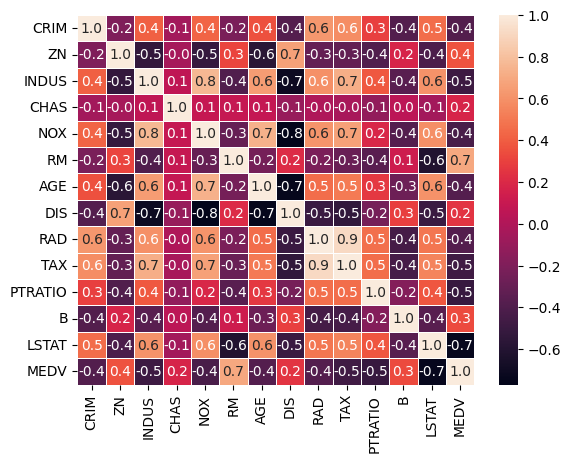

In [23]:
import seaborn as sn

plot = sn.heatmap(correlation, annot = True, fmt=".1f", linewidths=.6)
plot

- As variáveis RM e MEDV tem uma correlação alta, explicando o
obvio, que a quantidade de quartos em uma casa influencia
seu preço.

- As variaveis ZN e DIS são bem correlacionadas, o que explicaria isso seria a ideia de que quanto mais perto estamos em centros de emprego, mais povoado é o lugar o que torna mais dificil de ter residencias grandes.

- TAZ e INDUS são duas variaveis bem correlacionadas. Mas é preciso entender melhor a causalidade entre as variáveis.

- NOX(nivel de poluição do ar) tem uma correlação com DIS(proximidade com centros urbanos ), RAD(acesso facil a rodovias) e INDUS(proximidade com industrias não comerciais). Poderiamos explicar isso dizendo que centros urbanos, rodovias e industrias não comerciais produzirem mais oxído nitrico aumentando assim o indicador NOX.

- Podemos interpretar que propriedades com acesso fácil a rodovias influencia bastante a taxa de imposto na mesma.

- A variavel B ao qual representa a proporção de residentes negros, é uma variável que pode causar certas implicações éticas. É preciso considerar o impacto ético e social ao adicionar tais informações em conjunto de dados para um modelo preditivo. Em muitos contextos, o uso de variáveis relacionadas à raça, etnia ou outras características protegidas é regulamentado e pode ser proibido.

- Em geral as variaveis do conjunto de dados possuem uma correlação baixa a moderada. Precisa ser validado como a Regressão Linear performaria, levando em conta que é um algoritmo que pressupõe uma relação linear entre as variáveis.

### Outliers

In [9]:
! pip install pyod

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.6/169.6 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for pyod: filename=pyod-2.0.3-py3-none-any.whl size=200466 sha256=e7124e040d8afd52ec00e0d00cf1b1dc65ac59cd6e2e3f5bea206559f271f9f0
  Stored in directory: /root/.cache/pip/wheels/2d/60/5b/f74eccd2c9c892a2c298202ca510f10995f9940647fcc2d97f
Successfully built pyod


In [27]:
from pyod.models.knn import KNN

detector = KNN()
detector.fit(df)

prev = detector.labels_
prev

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

In [34]:
len(prev)

506

In [28]:
import numpy as np

np.count_nonzero(prev)


51

In [29]:
np.unique(prev, return_counts=True)

(array([0, 1]), array([455,  51]))

In [30]:
outliers = []
for i in range(len(prev)):
  if prev[i] == 1:
    outliers.append(i)

print(outliers)

[18, 25, 27, 32, 34, 48, 54, 74, 102, 118, 134, 145, 146, 153, 155, 156, 165, 167, 168, 170, 197, 199, 200, 214, 283, 286, 310, 328, 329, 330, 343, 346, 353, 367, 380, 404, 405, 409, 410, 413, 414, 417, 418, 444, 460, 465, 488, 489, 490, 491, 492]


In [35]:
lista_outliers = df.iloc[outliers,:]
lista_outliers

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV,outlier
18,0.80271,0.0,8.14,0,0.538,5.456,36.6,3.7965,4,307.0,21.0,288.99,11.69,20.2,0
25,0.84054,0.0,8.14,0,0.538,5.599,85.7,4.4546,4,307.0,21.0,303.42,16.51,13.9,0
27,0.95577,0.0,8.14,0,0.538,6.047,88.8,4.4534,4,307.0,21.0,306.38,17.28,14.8,0
32,1.38799,0.0,8.14,0,0.538,5.950,82.0,3.9900,4,307.0,21.0,232.60,27.71,13.2,0
34,1.61282,0.0,8.14,0,0.538,6.096,96.9,3.7598,4,307.0,21.0,248.31,20.34,13.5,0
48,0.25387,0.0,6.91,0,0.448,5.399,95.3,5.8700,3,233.0,17.9,396.90,30.81,14.4,0
54,0.01360,75.0,4.00,0,0.410,5.888,47.6,7.3197,3,469.0,21.1,396.90,14.80,18.9,0
74,0.07896,0.0,12.83,0,0.437,6.273,6.0,4.2515,5,398.0,18.7,394.92,6.78,24.1,0
102,0.22876,0.0,8.56,0,0.520,6.405,85.4,2.7147,5,384.0,20.9,70.80,10.63,18.6,0
118,0.13058,0.0,10.01,0,0.547,5.872,73.1,2.4775,6,432.0,17.8,338.63,15.37,20.4,0


Apesar dos outliers serem em uma quantidade consideravel, eu prefiro ir por uma abordagem mais direta e simplesmente remove-los. Assim não necessita a preocupação de como os modelos mais sensíveis vão reagir a esses dados.